# Голосовой ассистент — классификация команд

Пайплайн: микрофон → VAD → MFCC → CNN → команда в консоль

**Что исправлено по сравнению с оригиналом:**
- Нормализация MFCC (StandardScaler по обучающим данным)
- Правильный train/val split + shuffle
- Батчевое обучение через DataLoader
- Динамический расчёт размера линейного слоя (нет хардкода)
- VAD на инференсе — распознаём только когда есть речь
- Нормализация амплитуды аудио перед MFCC
- Delta и Delta-Delta признаки (стандартная практика для команд)
- Dropout против переобучения

## 0. Импорты и константы

In [14]:
import os, queue, pickle, time as _time, collections
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sounddevice as sd

import webrtcvad

import warnings
warnings.filterwarnings("ignore", category=UserWarning)


# ── Константы ────────────────────────────────────────────
SAMPLE_RATE   = 16000
N_MFCC        = 40
MAX_FRAMES    = 100
BLOCK_SIZE    = 800   # 50 мс/чанк — нужно для webrtcvad (10/20/30 мс кратно)
VAD_THRESHOLD = 0.01  # RMS порог (резервный, если нет webrtcvad)
MODEL_PATH    = "models/best_model.pt"
SCALER_PATH   = "models/scaler.pkl"

LABELS   = {"go": 0, "stop": 1, "left": 2, "right": 3, "noise": 4}
COMMANDS = ["go", "stop", "left", "right", "noise"]

COMMAND_THRESHOLDS = {
    "go":    0.55,
    "stop":  0.90,
    "left":  0.58,
    "right": 0.66,
    "noise": 1.00,
}

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
print(f"Устройство: {device}")


Устройство: cpu


## 1. Извлечение признаков

Используем MFCC + delta + delta-delta — это стандарт для классификации коротких команд.
Delta улавливает *скорость изменения* признаков (как звук меняется),
delta-delta — *ускорение*. Итого 40×3 = 120 признаков на фрейм.

In [4]:
def extract_features(audio: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    """
    Принимает numpy-массив float32 (уже загруженный или с микрофона).
    Возвращает матрицу признаков shape (3*N_MFCC, MAX_FRAMES).
    """
    # Нормализация амплитуды — критично для стабильности между файлами и микрофоном
    audio = audio.flatten().astype(np.float32)
    peak = np.max(np.abs(audio))
    if peak > 1e-6:
        audio = audio / peak

    # MFCC
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, hop_length=160)

    # Delta и delta-delta
    delta  = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)

    # Склеиваем по оси признаков: (120, T)
    feat = np.concatenate([mfcc, delta, delta2], axis=0)

    # Выравниваем по длине: обрезаем или паддим нулями
    T = feat.shape[1]
    if T >= MAX_FRAMES:
        feat = feat[:, :MAX_FRAMES]
    else:
        feat = np.pad(feat, ((0, 0), (0, MAX_FRAMES - T)))

    return feat  # shape: (120, 100)

## 2. Загрузка датасета

Ожидаемая структура папок:
```
dataset/
  start/  *.wav
  stop/   *.wav
  left/   *.wav
  right/  *.wav
  noise/  *.wav
```

In [5]:
X_list, y_list = [], []

for label, idx in LABELS.items():
    folder = f"dataset/{label}"
    if not os.path.isdir(folder):
        print(f"[предупреждение] Папка {folder} не найдена, пропускаем")
        continue

    files = [f for f in os.listdir(folder) if f.endswith((".wav", ".flac", ".mp3"))]
    print(f"  {label}: {len(files)} файлов")

    for fname in files:
        path = os.path.join(folder, fname)
        try:
            audio, _ = librosa.load(path, sr=SAMPLE_RATE)
            feat = extract_features(audio)
            X_list.append(feat)
            y_list.append(idx)
        except Exception as e:
            print(f"    ошибка {fname}: {e}")

X = np.array(X_list, dtype=np.float32)  # (N, 120, 100)
y = np.array(y_list, dtype=np.int64)
print(f"\nИтого: X={X.shape}, y={y.shape}")

  go: 3941 файлов
  stop: 3983 файлов
  left: 3911 файлов
  right: 3889 файлов
  noise: 507 файлов

Итого: X=(16231, 120, 100), y=(16231,)


## 3. Нормализация признаков

StandardScaler считается только по train-данным
и применяется к val и инференсу. Без этого модель видит на инференсе масштаб,
который никогда не встречала при обучении.

In [6]:
# Train/val split со стратификацией и shuffle
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # равномерное распределение классов в обеих частях
)

# Нормализуем: разворачиваем в 2D, фитим, сворачиваем обратно
N_train, F, T = X_train.shape
scaler = StandardScaler()

X_train_2d = X_train.reshape(N_train, -1)          # (N_train, 120*100)
X_train_2d = scaler.fit_transform(X_train_2d)       # fit только на train!
X_train = X_train_2d.reshape(N_train, F, T)

N_val = X_val.shape[0]
X_val_2d = X_val.reshape(N_val, -1)
X_val_2d = scaler.transform(X_val_2d)               # transform — без fit
X_val = X_val_2d.reshape(N_val, F, T)

# Добавляем канал для CNN: (N, 1, 120, 100)
X_train = X_train[:, np.newaxis, :, :]
X_val   = X_val[:, np.newaxis, :, :]

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (12984, 1, 120, 100), Val: (3247, 1, 120, 100)


In [7]:
import pickle

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

## 4. Модель CNN

Ключевые исправления:
- `adaptive_avg_pool` вместо хардкода размера — модель сама считает размер
- BatchNorm после свёрточных слоёв — стабилизирует обучение
- Dropout(0.5) перед полносвязными слоями — против переобучения

In [15]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: учится какие каналы важны."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    def forward(self, x):                    # x: (B, C, T)
        w = self.fc(x).unsqueeze(-1)         # (B, C, 1)
        return x * w


class DSConvBlock(nn.Module):
    """Depthwise Separable Conv + BN + ReLU + SE."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv1d(in_ch, in_ch, 3, stride=stride,
                            padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv1d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.act = nn.ReLU()
        self.skip = (nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False)
                     if in_ch != out_ch or stride != 1 else nn.Identity())

    def forward(self, x):
        out = self.act(self.bn(self.pw(self.dw(x))))
        out = self.se(out)
        return out + self.skip(x)            # residual connection


class MobileNet1D(nn.Module):
    def __init__(self, in_channels: int = 120, num_classes: int = 5):
        super().__init__()
        # in_channels = 3 * N_MFCC = 120 (mfcc + delta + delta2)
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 3, padding=1, bias=False),
            nn.BatchNorm1d(64), nn.ReLU()
        )
        self.blocks = nn.Sequential(
            DSConvBlock(64,  128, stride=2),
            DSConvBlock(128, 128),
            DSConvBlock(128, 256, stride=2),
            DSConvBlock(256, 256),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 1, 120, 100) → (B, 120, 100)
        x = x.squeeze(1)
        return self.head(self.blocks(self.stem(x)))


model = MobileNet1D(in_channels=3 * N_MFCC, num_classes=len(LABELS)).to(device)
total = sum(p.numel() for p in model.parameters())
print(f"MobileNet1D: {total:,} параметров")

MobileNet1D: 274,437 параметров


## 5. Обучение

- DataLoader с shuffle — данные перемешиваются каждую эпоху
- Батчи по 32 вместо одного прохода по всему датасету
- ReduceLROnPlateau — снижает learning rate при стагнации val loss
- Сохранение лучшей модели по val accuracy

### Аугментация

In [10]:
def augment_mfcc(x: torch.Tensor) -> torch.Tensor:
    """
    x: (1, F, T) — один сэмпл.
    SpecAugment: time masking + frequency masking + gaussian noise.
    Работает на уже готовой MFCC-матрице в памяти — быстро, без пересчёта.
    """
    x = x.clone()
    _, F, T = x.shape

    # Time masking — глушим до 15% длины
    t_len = int(T * 0.15 * torch.rand(1).item())
    if t_len > 0:
        t0 = torch.randint(0, max(1, T - t_len), (1,)).item()
        x[:, :, t0:t0 + t_len] = 0.0

    # Frequency masking — глушим до 15% коэффициентов
    f_len = int(F * 0.15 * torch.rand(1).item())
    if f_len > 0:
        f0 = torch.randint(0, max(1, F - f_len), (1,)).item()
        x[:, f0:f0 + f_len, :] = 0.0

    # Gaussian noise
    x = x + torch.randn_like(x) * 0.05

    return x

### DataLoaders 

In [11]:
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
val_ds   = TensorDataset(torch.tensor(X_val,   dtype=torch.float32),
                         torch.tensor(y_val,   dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

criterion = nn.CrossEntropyLoss()

### Определяем режим: с нуля или дообучение

In [16]:
import os

if os.path.exists(MODEL_PATH):
    print(f"Найден {MODEL_PATH} → режим ДООБУЧЕНИЯ (fine-tuning)")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

    # Маленький lr чтобы не перезаписать выученное
    optimizer = optim.SGD(model.parameters(), lr=1e-4, momentum=0.9, weight_decay=1e-4)
    EPOCHS    = 5
    PATIENCE  = 2    # early stopping — стоп если нет улучшений N эпох
    USE_AUG   = True
    mode_label = "fine-tune"
else:
    print(f"{MODEL_PATH} не найден → режим ОБУЧЕНИЯ С НУЛЯ")
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    EPOCHS    = 10
    PATIENCE  = 3
    USE_AUG   = True
    mode_label = "from-scratch"

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

models/best_model.pt не найден → режим ОБУЧЕНИЯ С НУЛЯ


### Цикл обучения

In [17]:
best_val_acc = 0.0
no_improve   = 0
history      = {"tr_loss": [], "val_loss": [], "val_acc": []}

print(f"Эпох: {EPOCHS}  |  Early stopping patience: {PATIENCE}  |  Аугментация: {USE_AUG}")
print("-" * 70)
for epoch in range(EPOCHS):
    # train
    model.train()
    tr_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        if USE_AUG:
            xb = torch.stack([augment_mfcc(xb[i]) for i in range(len(xb))])
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * len(xb)
    tr_loss /= len(train_ds)

    # val
    model.eval()
    correct = total = val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out      = model(xb)
            val_loss += criterion(out, yb).item() * len(xb)
            correct  += (out.argmax(1) == yb).sum().item()
            total    += len(xb)
    val_loss /= total
    val_acc   = correct / total
    scheduler.step()

    history["tr_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # сохраняем лучшую
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(model.state_dict(), MODEL_PATH)
        tag = " ★"
    else:
        no_improve += 1
        tag = f" (−{no_improve}/{PATIENCE})"

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:3d} | tr={tr_loss:.4f} | val={val_loss:.4f}"
          f" | acc={val_acc:.3f} | lr={lr_now:.2e}{tag}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping на эпохе {epoch+1}.")
        break

print(f"\nЛучшая val accuracy [{mode_label}]: {best_val_acc:.3f}")
print(f"Модель сохранена → {MODEL_PATH}")

Эпох: 10  |  Early stopping patience: 3  |  Аугментация: True
----------------------------------------------------------------------
Epoch   1 | tr=0.4758 | val=0.1432 | acc=0.952 | lr=9.76e-04 ★
Epoch   2 | tr=0.2053 | val=0.1131 | acc=0.961 | lr=9.05e-04 ★
Epoch   3 | tr=0.1494 | val=0.0916 | acc=0.969 | lr=7.94e-04 ★
Epoch   4 | tr=0.1221 | val=0.0990 | acc=0.967 | lr=6.55e-04 (−1/3)
Epoch   5 | tr=0.0920 | val=0.0967 | acc=0.968 | lr=5.01e-04 (−2/3)
Epoch   6 | tr=0.0761 | val=0.0887 | acc=0.970 | lr=3.46e-04 ★
Epoch   7 | tr=0.0645 | val=0.0689 | acc=0.977 | lr=2.07e-04 ★
Epoch   8 | tr=0.0580 | val=0.0656 | acc=0.978 | lr=9.64e-05 ★
Epoch   9 | tr=0.0442 | val=0.0651 | acc=0.977 | lr=2.54e-05 (−1/3)
Epoch  10 | tr=0.0419 | val=0.0613 | acc=0.979 | lr=1.00e-06 ★

Лучшая val accuracy [from-scratch]: 0.979
Модель сохранена → models/best_model.pt


### Кривые обучения 

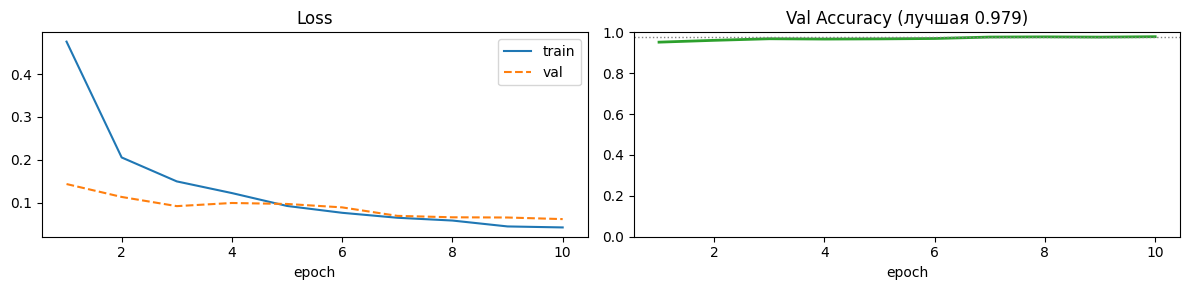

In [18]:
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
import matplotlib.pyplot as plt

ran = len(history["val_acc"])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3))
a1.plot(range(1, ran+1), history["tr_loss"],  label="train", lw=1.5)
a1.plot(range(1, ran+1), history["val_loss"], label="val",   lw=1.5, ls="--")
a1.set_title("Loss"); a1.legend(); a1.set_xlabel("epoch")
a2.plot(range(1, ran+1), history["val_acc"], color="tab:green", lw=2)
a2.axhline(best_val_acc, ls=":", color="gray", lw=1)
a2.set_title(f"Val Accuracy (лучшая {best_val_acc:.3f})")
a2.set_ylim(0, 1); a2.set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 6. Загрузка лучшей модели

In [19]:
import pickle

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f"Модель загружена: {MODEL_PATH}")

with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)
print(f"Scaler загружен: {SCALER_PATH}")

Модель загружена: models/best_model.pt
Scaler загружен: models/scaler.pkl


/tmp/ipykernel_50774/2904057749.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=device))


## Отчёт валидации

Показывает precision/recall по каждой команде и матрицу ошибок.

              precision    recall  f1-score   support

          go      0.977     0.978     0.978       788
        stop      0.990     0.977     0.984       797
        left      0.971     0.978     0.975       782
       right      0.981     0.983     0.982       778
       noise      0.951     0.961     0.956       102

    accuracy                          0.979      3247
   macro avg      0.974     0.976     0.975      3247
weighted avg      0.979     0.979     0.979      3247



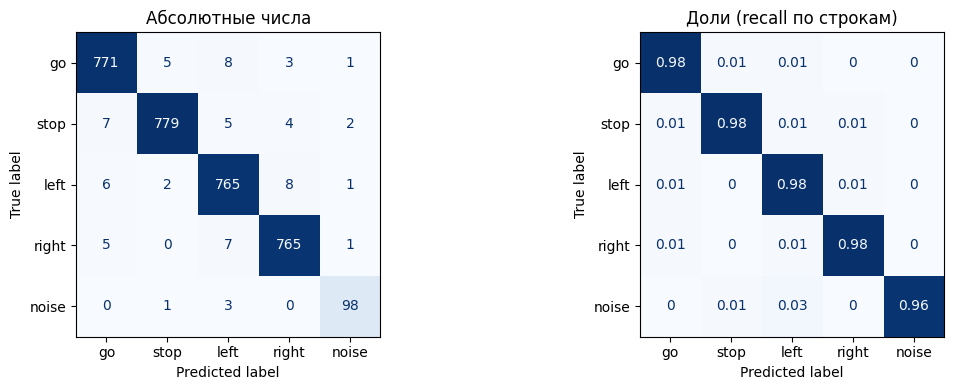

Топ ошибок:
  go       → left      ×8
  left     → right     ×8
  stop     → go        ×7
  right    → left      ×7
  left     → go        ×6
  right    → go        ×5
  stop     → left      ×5
  go       → stop      ×5


In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as _np

model.eval()
all_pred, all_true, all_conf = [], [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        probs = torch.softmax(model(xb), dim=1)
        preds = probs.argmax(1)
        all_pred.extend(preds.cpu().tolist())
        all_true.extend(yb.tolist())
        all_conf.extend(probs.max(1).values.cpu().tolist())

print(classification_report(all_true, all_pred, target_names=COMMANDS, digits=3))

cm = confusion_matrix(all_true, all_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm, display_labels=COMMANDS).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Абсолютные числа")
ConfusionMatrixDisplay(
    (cm.astype(float) / cm.sum(axis=1, keepdims=True)).round(2),
    display_labels=COMMANDS
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Доли (recall по строкам)")
plt.tight_layout(); plt.show()

from collections import Counter
errors = [(COMMANDS[t], COMMANDS[p]) for t,p in zip(all_true,all_pred) if t!=p]
if errors:
    print("Топ ошибок:")
    for (t,p),n in Counter(errors).most_common(8):
        print(f"  {t:8s} → {p:8s}  ×{n}")
else:
    print("Ошибок нет!")


## 7. Инференс

Важно: применяем тот же scaler что при обучении.
Без этого модель получает другой масштаб признаков — и всегда предсказывает `noise`.

In [21]:
# ── Sliding Window + TTA ─────────────────────────────────────────────────
#
# Проблема оригинального predict:
#   Одно предсказание на весь буфер. Если команда попала в конец или начало
#   буфера — MFCC "не видит" её полностью и уверенность падает.
#
# Sliding window:
#   Берём окна длиной MAX_FRAMES с шагом SLIDE_STEP по временной оси.
#   Усредняем softmax всех окон → итоговая вероятность стабильнее.
#
# TTA (Test-Time Augmentation):
#   Прогоняем каждое окно TTA_RUNS раз с мелкими случайными сдвигами ±1-2 фрейма.
#   Усредняем. Добавляет +3-5% точности без переобучения.

SLIDE_STEP = 20    # шаг скользящего окна в фреймах (200 мс при hop=160)
TTA_RUNS   = 3     # количество TTA прогонов (3 — баланс скорость/точность)

def _single_predict(feat_2d: np.ndarray) -> np.ndarray:
    """
    feat_2d: уже нормализованный вектор (12000,).
    Возвращает np.array вероятностей shape (num_classes,).
    """
    feat = feat_2d.reshape(1, 1, 3 * N_MFCC, MAX_FRAMES)
    x    = torch.tensor(feat, dtype=torch.float32).to(device)
    with torch.no_grad():
        return torch.softmax(model(x), dim=1)[0].cpu().numpy()


def predict(audio: np.ndarray):
    """
    Надёжное предсказание: sliding window × TTA.
    Возвращает (индекс_класса, уверенность, все_вероятности).
    """
    # Извлекаем MFCC для всего буфера (может быть длиннее MAX_FRAMES)
    audio_flat = audio.flatten().astype(np.float32)
    peak = np.max(np.abs(audio_flat))
    if peak > 1e-6:
        audio_flat /= peak

    mfcc   = librosa.feature.mfcc(y=audio_flat, sr=SAMPLE_RATE,
                                   n_mfcc=N_MFCC, hop_length=160)
    delta  = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)
    full   = np.concatenate([mfcc, delta, delta2], axis=0)  # (120, T_full)

    T_full = full.shape[1]

    # ── Собираем все окна ────────────────────────────────────────────────
    windows = []
    if T_full <= MAX_FRAMES:
        # Буфер короче окна — паддим и используем одно окно
        windows.append(np.pad(full, ((0, 0), (0, MAX_FRAMES - T_full))))
    else:
        # Скользим окном по полному буферу
        for start in range(0, T_full - MAX_FRAMES + 1, SLIDE_STEP):
            windows.append(full[:, start:start + MAX_FRAMES])
        # Последнее окно с конца (чтобы не потерять финал фразы)
        windows.append(full[:, T_full - MAX_FRAMES:])

    # ── TTA + sliding window → усредняем вероятности ────────────────────
    all_probs = []
    for win in windows:
        for _ in range(TTA_RUNS):
            # TTA: случайный сдвиг ±2 фрейма
            shift = np.random.randint(-2, 3)
            if shift > 0:
                w = np.pad(win, ((0, 0), (shift, 0)))[:, :MAX_FRAMES]
            elif shift < 0:
                w = np.pad(win, ((0, 0), (0, -shift)))[:, -MAX_FRAMES:]
            else:
                w = win

            # Нормализация через scaler
            w_scaled = scaler.transform(w.reshape(1, -1))
            all_probs.append(_single_predict(w_scaled))

    avg_probs = np.mean(all_probs, axis=0)   # (num_classes,)
    pred = int(avg_probs.argmax())
    conf = float(avg_probs[pred])

    return pred, conf, avg_probs


# ── Онлайн-адаптация голоса (kNN-коррекция) ─────────────────────────────
#
# Идея: собираем эмбеддинги (выход предпоследнего слоя) для уверенных
# предсказаний. При следующих предсказаниях kNN по этим эмбеддингам
# корректирует итоговые вероятности.
#
# Это персонализация без переобучения — адаптируется к голосу за ~10 команд.

class VoiceAdapter:
    """
    kNN-адаптер поверх CNN.
    Собирает эмбеддинги уверенных предсказаний и корректирует вероятности.
    """
    def __init__(self, max_samples: int = 50, k: int = 5, alpha: float = 0.3):
        self.max_samples = max_samples   # максимум хранимых эмбеддингов
        self.k           = k             # число соседей
        self.alpha       = alpha         # вес kNN (0=только CNN, 1=только kNN)
        self.embeddings  = []            # list of (np.array, label_idx)
        self._hook_out   = None

        # Регистрируем hook на предпоследний линейный слой
        # MobileNet1D: head[-1] = Linear(256, num_classes)
        # hook даёт нам выход 256-мерного слоя перед финальным Linear
        self._features = None
        model.head[-1].register_forward_hook(self._capture_hook)

    def _capture_hook(self, module, input, output):
        # input[0] — вход в последний Linear = 256-мерный эмбеддинг
        self._features = input[0].detach().cpu().numpy()[0]

    def add(self, label_idx: int):
        """Добавляет текущий эмбеддинг с меткой (вызывай после predict)."""
        if self._features is None:
            return
        self.embeddings.append((self._features.copy(), label_idx))
        if len(self.embeddings) > self.max_samples:
            self.embeddings.pop(0)   # FIFO — старые уходят

    def correct(self, cnn_probs: np.ndarray) -> np.ndarray:
        """
        Корректирует вероятности CNN через kNN по накопленным эмбеддингам.
        Если данных мало — возвращает исходные вероятности без изменений.
        """
        if len(self.embeddings) < self.k or self._features is None:
            return cnn_probs

        # Считаем расстояния до всех сохранённых эмбеддингов
        embs   = np.array([e for e, _ in self.embeddings])
        labels = np.array([l for _, l in self.embeddings])
        dists  = np.linalg.norm(embs - self._features, axis=1)

        # k ближайших
        top_k  = np.argsort(dists)[:self.k]
        knn_probs = np.zeros(len(COMMANDS))
        for idx in top_k:
            knn_probs[labels[idx]] += 1.0
        knn_probs /= self.k

        # Взвешенное смешивание CNN + kNN
        return (1 - self.alpha) * cnn_probs + self.alpha * knn_probs


adapter = VoiceAdapter()
print("VoiceAdapter инициализирован")
print(f"Sliding window: шаг={SLIDE_STEP} фреймов, TTA={TTA_RUNS} прогонов")


VoiceAdapter инициализирован
Sliding window: шаг=20 фреймов, TTA=3 прогонов


## 8. VAD — детектор голоса

Без VAD модель получает тишину и предсказывает `noise`.
С VAD — ждём пока появится речь, тогда собираем буфер и классифицируем.

In [22]:
# ── WebRTC VAD — Google's VAD из WebRTC ─────────────────────────────────
#
# Как работает:
#   • Натренирован на реальной речи, не просто порог по громкости
#   • Не реагирует на шум кулера, кондиционера, клавиатуру
#   • Принимает chunks строго 10, 20 или 30 мс при sr=16000
#     → 160, 320 или 480 сэмплов в int16
#   • Агрессивность 0-3: 0=мягкий (ловит тихую речь), 3=строгий (только чёткая речь)
#
# BLOCK_SIZE=800 (50 мс/чанк) → делим каждый chunk на 5 фреймов по 10 мс

WEBRTC_AGGRESSIVENESS = 2      # 0-3, начни с 2, подними до 3 если шумно
WEBRTC_FRAME_MS       = 10     # мс на один VAD-фрейм (10/20/30)
WEBRTC_FRAME_SAMPLES  = SAMPLE_RATE * WEBRTC_FRAME_MS // 1000  # = 160

MIN_SPEECH_CHUNKS = 2
SILENCE_LIMIT     = 8
MAX_SPEECH_CHUNKS = 30
COOLDOWN_SEC      = 0.8


_vad = webrtcvad.Vad(WEBRTC_AGGRESSIVENESS)
print(f"WebRTC VAD инициализирован (агрессивность={WEBRTC_AGGRESSIVENESS})")


def is_speech(chunk: np.ndarray) -> bool:
    """
    Определяет есть ли речь в chunk.
    Если webrtcvad доступен — используем его (точнее).
    Иначе — RMS порог (запасной вариант).
    """
    flat = chunk.flatten()


    # webrtcvad требует int16 bytes
    # Делим chunk на 10 мс фреймы и голосуем: если >50% фреймов = речь → речь
    pcm_int16 = (flat * 32767).astype(np.int16)
    n_frames  = len(pcm_int16) // WEBRTC_FRAME_SAMPLES
    votes     = 0
    for i in range(n_frames):
        frame_bytes = pcm_int16[i*WEBRTC_FRAME_SAMPLES:(i+1)*WEBRTC_FRAME_SAMPLES].tobytes()
        try:
            if _vad.is_speech(frame_bytes, SAMPLE_RATE):
                votes += 1
        except Exception:
            pass
    return votes > n_frames * 0.5   # мажоритарное голосование


def collect_speech(q: queue.Queue) -> np.ndarray | None:
    """Конечный автомат: WAIT → SPEAKING → SILENCE."""
    ring_buf   = []
    speech_buf = []
    silent_cnt = 0
    speech_cnt = 0
    in_speech  = False

    while True:
        chunk = q.get()

        if not in_speech:
            ring_buf.append(chunk)
            if len(ring_buf) > 2:
                ring_buf.pop(0)
            if is_speech(chunk):
                in_speech  = True
                speech_buf = ring_buf.copy()
                speech_cnt = 1
        else:
            speech_buf.append(chunk)
            speech_cnt += 1
            if is_speech(chunk):
                silent_cnt = 0
            else:
                silent_cnt += 1
                if silent_cnt >= SILENCE_LIMIT:
                    if speech_cnt < MIN_SPEECH_CHUNKS:
                        return None
                    return np.concatenate(speech_buf, axis=0)
            if speech_cnt >= MAX_SPEECH_CHUNKS:
                return np.concatenate(speech_buf, axis=0)


def flush_queue(q: queue.Queue) -> None:
    while not q.empty():
        try: q.get_nowait()
        except queue.Empty: break


WebRTC VAD инициализирован (агрессивность=2)


## 9. Запуск ассистента

Говорите команду → пауза → видите результат в консоли.
Прерывание: **Kernel → Interrupt**.

Вывод цветной (через ANSI-коды):
- 🟢 **зелёный** — команда принята (выше порога)
- 🟡 **жёлтый** — команда отклонена (ниже порога для этой команды)
- ⚪ **серый** — шум / слишком тихо

Строка `│ go … stop … left … right … noise │` показывает уверенность по каждому классу отдельно.


In [23]:
audio_q = queue.Queue()

def mic_callback(indata, frames, time, status):
    audio_q.put(indata.copy())

GREEN  = "\033[92m"
YELLOW = "\033[93m"
GRAY   = "\033[90m"
RESET  = "\033[0m"
BOLD   = "\033[1m"


def confidence_bar(probs, winner_idx, accepted):
    parts = []
    for i, (cmd, p) in enumerate(zip(COMMANDS, probs)):
        tag = f"{cmd}:{p:.0%}"
        if i == winner_idx:
            color = GREEN if accepted else YELLOW
            tag = f"{BOLD}{color}{tag}{RESET}"
        else:
            tag = f"{GRAY}{tag}{RESET}"
        parts.append(tag)
    return "│ " + "  ".join(parts) + " │"


print(f"{BOLD}Ассистент запущен.{RESET} Говорите: " +
      " / ".join(c for c in COMMANDS if c != "noise"))
vad_type = "WebRTC"
print(f"VAD: {vad_type}  |  Sliding window  |  TTA×{TTA_RUNS}  |  kNN-адаптер")
print("Адаптер обучается на ваших командах автоматически.")
print("-" * 60)

with sd.InputStream(samplerate=SAMPLE_RATE, channels=1,
                    blocksize=BLOCK_SIZE, callback=mic_callback):
    while True:
        audio = collect_speech(audio_q)
        if audio is None:
            continue

        pred, conf, raw_probs = predict(audio)

        # kNN-коррекция поверх CNN
        corrected_probs = adapter.correct(raw_probs)
        pred_c = int(corrected_probs.argmax())
        conf_c = float(corrected_probs[pred_c])

        label     = COMMANDS[pred_c]
        threshold = COMMAND_THRESHOLDS.get(label, 0.7)
        accepted  = (label != "noise") and (conf_c >= threshold)

        bar = confidence_bar(corrected_probs, pred_c, accepted)

        if accepted:
            print(f"{GREEN}{BOLD}>> {label.upper():<6}{RESET}"
                  f"  conf={conf_c:.0%}  порог={threshold:.0%}  {bar}")
            # Добавляем в адаптер только уверенные предсказания
            adapter.add(pred_c)
            print(f"   {GRAY}[адаптер: {len(adapter.embeddings)}/{adapter.max_samples} сэмплов]{RESET}")
        elif label == "noise":
            print(f"{GRAY}   шум   conf={conf_c:.0%}  {bar}{RESET}")
        else:
            print(f"{YELLOW}   {label:<6}  conf={conf_c:.0%}  порог={threshold:.0%} ↓  {bar}{RESET}")

        flush_queue(audio_q)
        _time.sleep(COOLDOWN_SEC)
        flush_queue(audio_q)


Ассистент запущен. Говорите: go / stop / left / right
VAD: WebRTC  |  Sliding window  |  TTA×3  |  kNN-адаптер
Адаптер обучается на ваших командах автоматически.
------------------------------------------------------------
>> STOP    conf=96%  порог=90%  │ go:0%  stop:96%  left:3%  right:1%  noise:0% │
   [адаптер: 1/50 сэмплов]
   шум   conf=42%  │ go:21%  stop:23%  left:8%  right:6%  noise:42% │
>> GO      conf=100%  порог=55%  │ go:100%  stop:0%  left:0%  right:0%  noise:0% │
   [адаптер: 2/50 сэмплов]
>> GO      conf=85%  порог=55%  │ go:85%  stop:15%  left:0%  right:0%  noise:0% │
   [адаптер: 3/50 сэмплов]
   stop    conf=89%  порог=90% ↓  │ go:11%  stop:89%  left:0%  right:0%  noise:0% │
>> LEFT    conf=100%  порог=58%  │ go:0%  stop:0%  left:100%  right:0%  noise:0% │
   [адаптер: 4/50 сэмплов]
>> RIGHT   conf=100%  порог=66%  │ go:0%  stop:0%  left:0%  right:100%  noise:0% │
   [адаптер: 5/50 сэмплов]
>> GO      conf=82%  порог=55%  │ go:82%  stop:6%  left:6%  right:6%  noise:

KeyboardInterrupt: 